# Section 5b — RQ3: why the within-model permutation test cannot answer the question, and what replaces it

This notebook does two things:

1. **Proves** that the current per-session permutation test has a *combinatorial* power ceiling,
   that the four sessions are not on a common scale, and that `ChronoGroupsSplit` silently
   discards blocks in one session.
2. **Shows the replacement** — a group-level restricted permutation test — computed *exactly*
   (no Monte Carlo) on the real stored latents, and validated for size and power on synthetic
   data with the same block structure.

Inputs (both produced on `bobby@neuro`, where `results/` lives):

| file | produced by | what it holds |
|---|---|---|
| `results/null_calibration_psid_zbehavior_Xp.json` | `scripts/check_null_calibration.py` | the **complete** permutation null of CV balanced accuracy for each session — every distinct block→label assignment, not a 500-draw sample |
| `results/group_perm_simulation.json` | `scripts/simulate_group_permutation.py` | size + power of four candidate tests on synthetic data matching the real block structure |

Scope of the real-data numbers: PSID, `z-as-behavior`, `dbs_both`, `predictions` mode, feature source `Xp`.
One cell of the family. The point here is the *method*, not this cell's result.

In [1]:
import sys, os

os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

import itertools
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from modules.style import (
    COLOR_CHANCE,
    COLOR_NS,
    COLOR_PSID,
    COLOR_DBS_ON,
    apply_thesis_style,
    panel_label,
)
from modules.sec2_common import SESSION_COLORS

apply_thesis_style()

OUT = Path("thesis_figures/sec5b")
OUT.mkdir(parents=True, exist_ok=True)

CALIB = json.loads(Path("results/null_calibration_psid_zbehavior_Xp.json").read_text())
CALIB = {r["session"]: r for r in CALIB}
SESSIONS = list(CALIB)

SIM_PATH = Path("results/group_perm_simulation.json")
SIM = json.loads(SIM_PATH.read_text()) if SIM_PATH.exists() else None

ALPHA = 0.05
print("sessions:", SESSIONS)
print("simulation loaded:", SIM is not None)

sessions: ['PDI1_S2', 'PDI1_S4', 'PDI4_S2', 'PDI4_S3']
simulation loaded: True


## Part 1 — The ceiling is combinatorial, not statistical

DBS condition is constant within a block, so the only thing that can be permuted is the
**block → label** assignment. For a session with $B$ blocks of which $k$ are ON, the entire
exchangeable set has

$$|\mathcal{G}_s| = \binom{B}{k}$$

elements. The observed labelling is always one of them and always ties itself, so the smallest
p-value the test can *ever* return is $1/|\mathcal{G}_s|$ — before any consideration of effect size.

`training/sweep.py` draws 500 random permutations from this set. Below, every element is
enumerated instead, which gives the **exact** null and the exact p, at a fraction of the cost
(70 + 20 + 20 + 15 = 125 model fits versus 4 × 500 = 2000).

In [2]:
hdr = f"{'session':10s} {'B':>2s} {'on/off':>7s} {'|G|':>5s} {'uniq BA':>8s} " \
      f"{'null mu':>8s} {'null SD':>8s} {'obs BA':>7s} {'exact p':>8s} {'floor':>7s}"
print(hdr)
print("-" * len(hdr))
# The attainable floor is NOT 1/|G|. Relabelling ON<->OFF refits LDA to the mirror
# classifier and returns the identical BA, so in a balanced session every labelling
# has a twin and the best possible p is 2/|G|. Compute it from the null itself.
FLOOR = {}
for s in SESSIONS:
    null = np.asarray(CALIB[s]["null_values"])
    FLOOR[s] = float((null >= null.max() - 1e-12).sum() / null.size)

for s in SESSIONS:
    r = CALIB[s]
    print(
        f"{s:10s} {r['n_blocks']:2d} {r['blocks_on']:3d}/{r['blocks_off']:<3d} "
        f"{r['null_support']:5d} {r['null_unique_values']:8d} "
        f"{r['null_mean']:8.4f} {r['null_sd']:8.4f} {r['cv_ba']:7.4f} "
        f"{r['exact_p']:8.4f} {FLOOR[s]:7.4f}"
    )

print()
for s in SESSIONS:
    r = CALIB[s]
    null = np.asarray(r["null_values"])
    n_tied = int((null >= null.max() - 1e-12).sum())
    verdict = "CAN reach p<0.05" if FLOOR[s] < ALPHA else "CANNOT reach p<0.05"
    print(f"{s:10s} best null BA {null.max():.4f} attained by {n_tied} labelling(s) "
          f"-> floor {FLOOR[s]:.4f}; a *perfect* classifier {verdict}")

print()
print("how far outside the null does the observed BA actually sit?")
for s in SESSIONS:
    r = CALIB[s]
    null = np.asarray(r["null_values"])
    obs, mu, sd = r["cv_ba"], null.mean(), null.std(ddof=1)
    below = null[null < obs - 1e-12]
    gap = obs - below.max() if below.size else float("nan")
    print(f"  {s:10s} obs={obs:.4f}  z={(obs - mu) / sd:+.2f}  "
          f"next-highest permutation={below.max() if below.size else float('nan'):.4f}  "
          f"gap={gap:+.4f}  exact p={r['exact_p']:.4f}")

session     B  on/off   |G|  uniq BA  null mu  null SD  obs BA  exact p   floor
-------------------------------------------------------------------------------
PDI1_S2     8   4/4      70       33   0.5097   0.0260  0.5149   0.4571  0.0286
PDI1_S4     6   3/3      20       10   0.5112   0.1450  0.6930   0.1000  0.1000
PDI4_S2     6   3/3      20       10   0.5067   0.1149  0.4941   0.5000  0.1000
PDI4_S3     6   4/2      15       13   0.4864   0.1069  0.7754   0.0667  0.0667

PDI1_S2    best null BA 0.5557 attained by 2 labelling(s) -> floor 0.0286; a *perfect* classifier CAN reach p<0.05
PDI1_S4    best null BA 0.6930 attained by 2 labelling(s) -> floor 0.1000; a *perfect* classifier CANNOT reach p<0.05
PDI4_S2    best null BA 0.7298 attained by 2 labelling(s) -> floor 0.1000; a *perfect* classifier CANNOT reach p<0.05
PDI4_S3    best null BA 0.7754 attained by 1 labelling(s) -> floor 0.0667; a *perfect* classifier CANNOT reach p<0.05

how far outside the null does the observed BA act

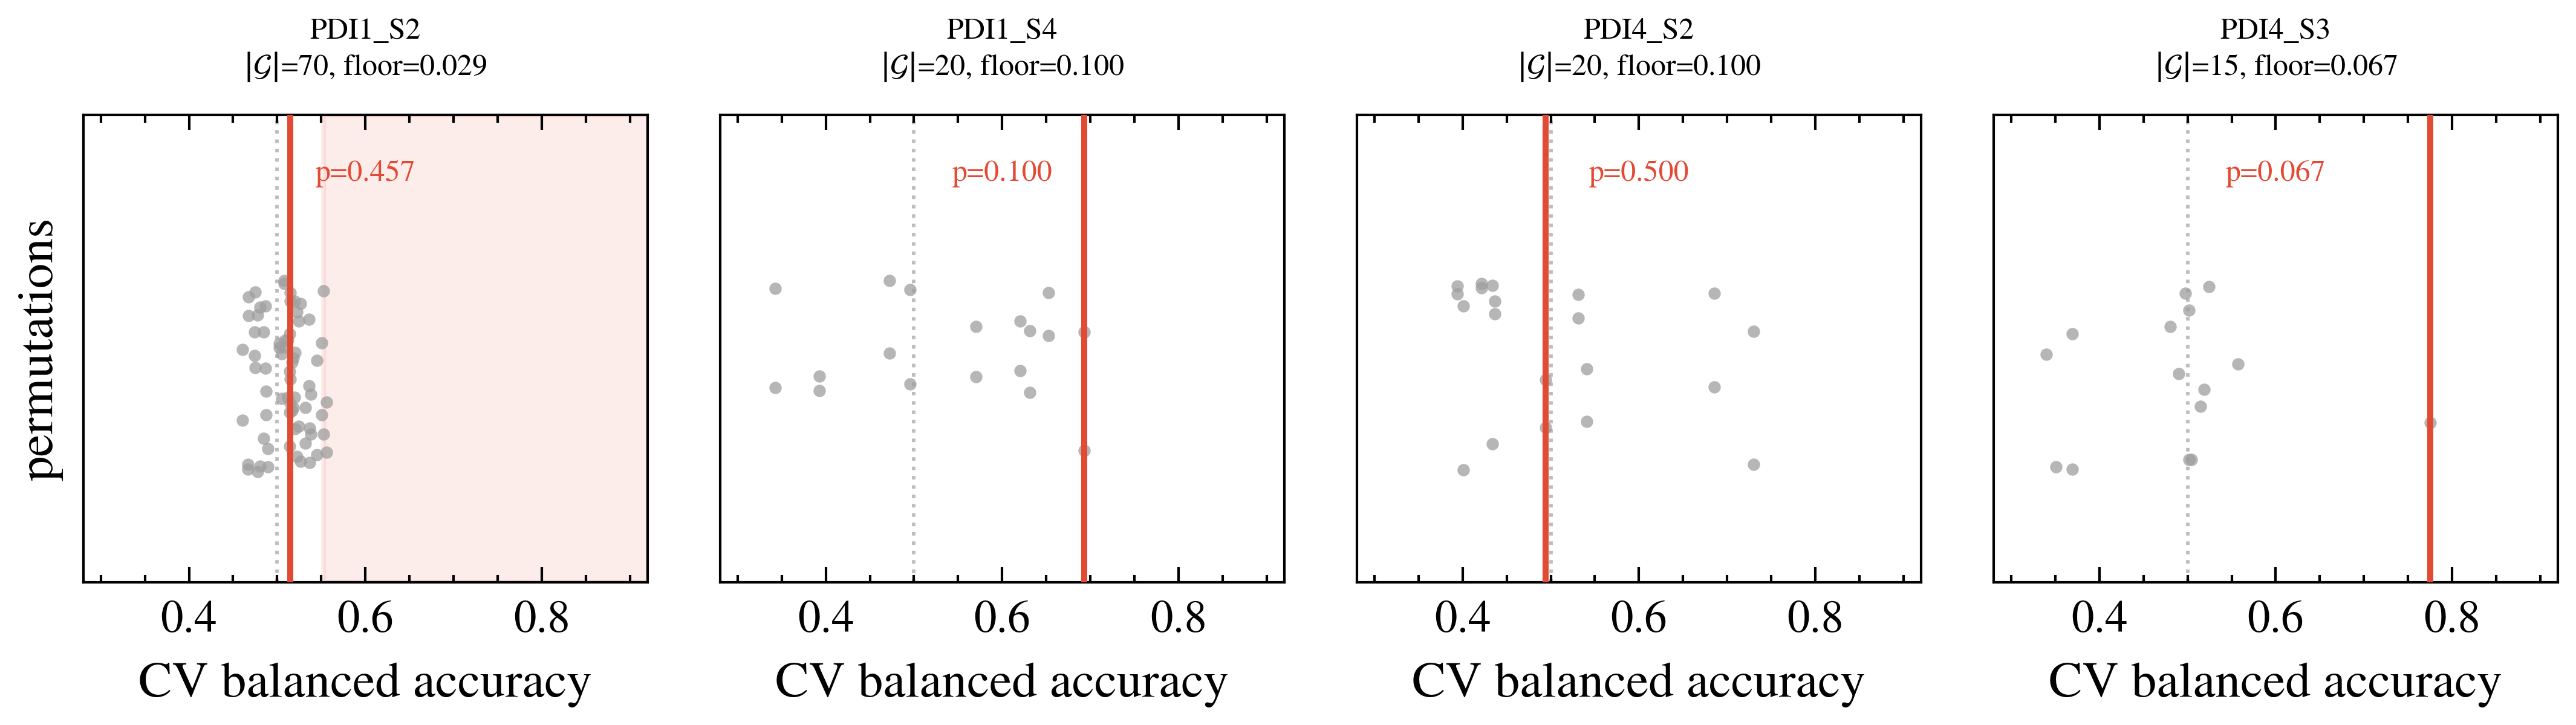

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(7.2, 2.1), sharex=True)
rng = np.random.default_rng(0)

for ax, s in zip(axes, SESSIONS):
    r = CALIB[s]
    null = np.asarray(r["null_values"])
    color = SESSION_COLORS.get(s, COLOR_PSID)

    # every enumerated labelling, jittered vertically
    ax.scatter(
        null,
        rng.uniform(-0.35, 0.35, size=null.size),
        s=6, color=COLOR_NS, alpha=0.75, linewidths=0, zorder=2,
    )
    # Rejection needs (#null >= obs)/|G| < alpha. The observed labelling ties itself,
    # and in a balanced session its ON<->OFF twin ties it too, so the attainable
    # region is the top ceil(alpha*|G|) - 1 values -- empty for |G| = 20 and 15.
    n_reject = int(np.ceil(ALPHA * null.size)) - 1
    if n_reject > 0:
        thresh = np.sort(null)[-n_reject]
        ax.axvspan(thresh, 1.0, color=COLOR_DBS_ON, alpha=0.10, zorder=1)
    ax.axvline(r["cv_ba"], color=COLOR_DBS_ON, lw=1.2, zorder=3)
    ax.axvline(0.5, color=COLOR_CHANCE, lw=0.7, ls=":", zorder=1)

    ax.set_yticks([])
    ax.set_ylim(-0.75, 0.95)
    ax.set_xlim(0.28, 0.92)
    ax.set_title(
        f"{s}\n$|\\mathcal{{G}}|$={r['null_support']}, floor={FLOOR[s]:.3f}",
        fontsize=6,
    )
    ax.text(
        0.5, 0.86, f"p={r['exact_p']:.3f}", transform=ax.transAxes,
        ha="center", fontsize=6, color=COLOR_DBS_ON,
    )

axes[0].set_ylabel("permutations")
for ax in axes:
    ax.set_xlabel("CV balanced accuracy")

fig.savefig(OUT / "fig_5b_01_exact_nulls.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding 1.** Red line = observed BA, grey dots = the complete null, shaded band = the
$\alpha=0.05$ rejection region.

- In **PDI1_S4** and **PDI4_S2** ($\binom{6}{3}=20$) and **PDI4_S3** ($\binom{6}{4}=15$) the
  shaded band is *empty*. Rejection requires $\#\{T^*\ge T\}/|\mathcal{G}| < 0.05$, and the
  observed labelling always ties itself, so the count is at least 1 — giving $p \ge 1/20 = 0.05$
  and $p \ge 1/15 = 0.067$. No labelling of the data, however perfectly separated, can produce
  $p < 0.05$. Only PDI1_S2 ($|\mathcal{G}|=70$) has a non-empty region: its top 3 values give
  $p \le 3/70 = 0.043$.
- **PDI4_S3** observes BA = 0.775 — the single best labelling out of 15 — and still returns
  $p = 0.067$. That is the floor, exactly. Note how far outside the null it sits: the
  next-highest permutation reaches only 0.557, a gap of 0.218, and $z = +2.70$. Against a
  *continuous* null that would be $p = 0.003$. The permutation test cannot say so, because it
  can only count labellings and there are 15 of them.
- **PDI1_S4** observes BA = 0.693 and returns $p = 0.100$ — two labellings tie it, not one.

**Why the floor is $2/|\mathcal{G}|$, not $1/|\mathcal{G}|$, in a balanced session.** Swapping
ON$\leftrightarrow$OFF everywhere refits LDA to the mirror classifier, which produces the
identical balanced accuracy. Every labelling therefore has a twin with exactly the same BA, and
the best attainable p is $2/|\mathcal{G}|$: 0.029 for PDI1_S2, 0.100 for PDI1_S4 and PDI4_S2.
PDI4_S3 is 4/2, so its complement has a different class size and is not in the set — its floor
stays $1/15 = 0.067$. These match the floors already quoted in `RESULTS_FIX_PLAN` §1.

**This is not a shortage of epochs.** The sessions hold 1633–2208 epochs each. It is a shortage
of *blocks*: DBS state is constant within a block, so the block is the exchangeable unit and 6
blocks give 20 labellings no matter how many epochs sit inside them. Permuting epoch labels
instead would give millions of permutations and tiny p-values — and would be invalid, because
epochs inside a block share that block's stimulation state and are autocorrelated. That is
pseudo-replication, and it is the thing block-level permutation exists to prevent.

Reporting these as "no DBS information" is reading a design limit as an empirical result.
More permutations cannot help: 500 draws from a 20-element set is 500 draws from a 20-element
set. The stored `n_permutations = 500` also explains the 9–15 unique null BA values noted in
`RESULTS_FIX_PLAN.md` M1 — the sampler keeps revisiting the same handful of assignments.

## Part 2 — The four sessions are not on a common scale

A pooled statistic has to combine the four sessions. The obvious choice, $\frac{1}{S}\sum_s T_s$,
is only valid if the four null distributions are comparable. They are not — and this has nothing
to do with whether the neural signal is stationary within a session. The spread of the *null*
is set by the resampling design: block count, fold count, epochs per block, class balance.

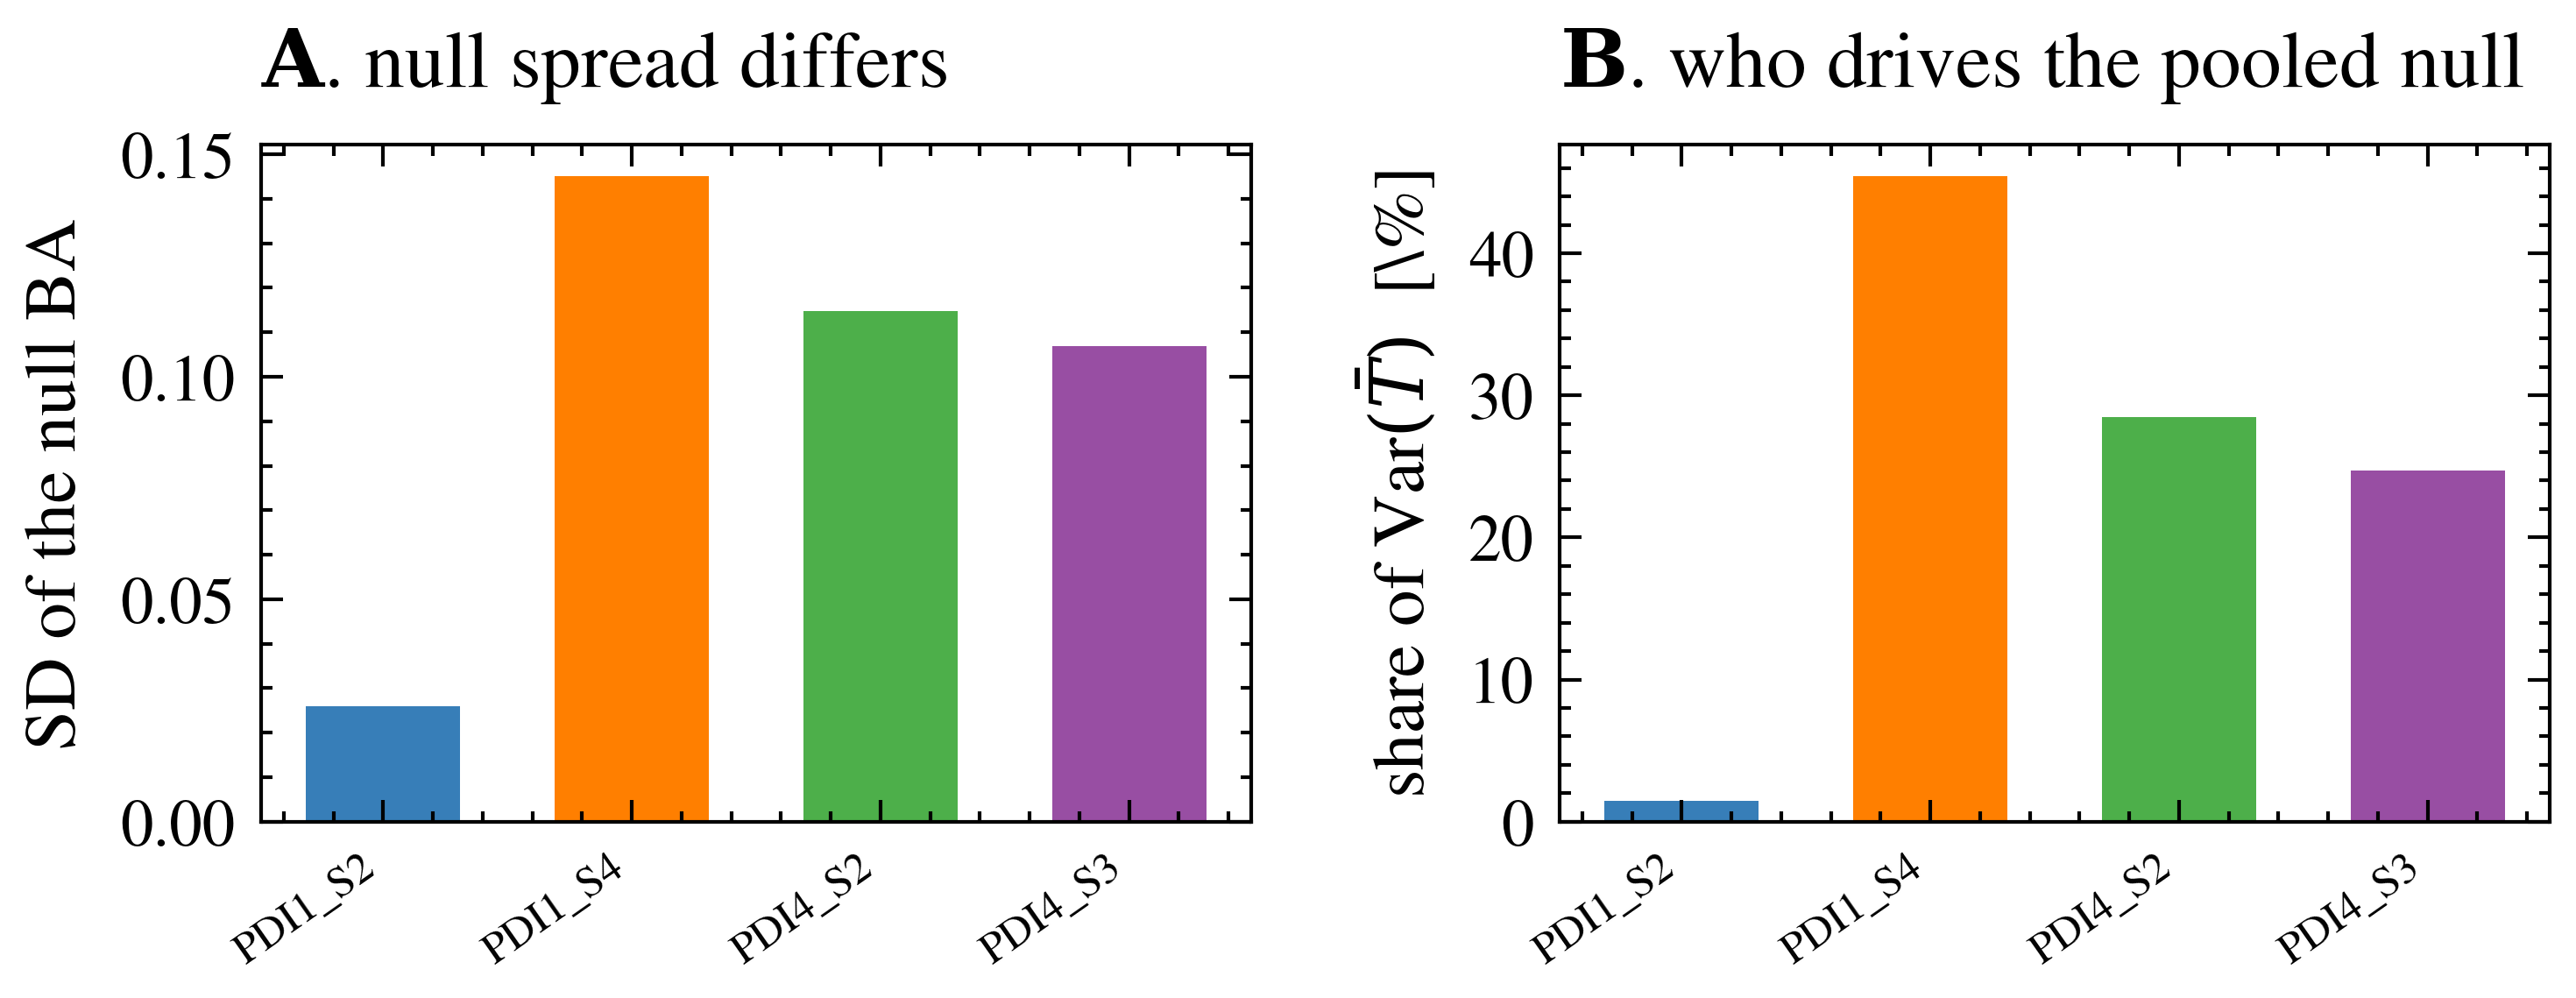

null means:  [0.5097 0.5112 0.5067 0.4864]   (max |mu - 0.5| = 0.0136)
null SDs:    [0.026  0.145  0.1149 0.1069]   (max/min = 5.58x)

  PDI1_S2    contributes   1.5% of the variance of the raw mean statistic
  PDI1_S4    contributes  45.4% of the variance of the raw mean statistic
  PDI4_S2    contributes  28.5% of the variance of the raw mean statistic
  PDI4_S3    contributes  24.7% of the variance of the raw mean statistic


In [4]:
mus = np.array([CALIB[s]["null_mean"] for s in SESSIONS])
sds = np.array([CALIB[s]["null_sd"] for s in SESSIONS])
var_share = sds**2 / (sds**2).sum()

fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.0))

colors = [SESSION_COLORS.get(s, COLOR_PSID) for s in SESSIONS]
axes[0].bar(range(len(SESSIONS)), sds, color=colors, width=0.62)
axes[0].set_xticks(range(len(SESSIONS)))
axes[0].set_xticklabels(SESSIONS, rotation=35, ha="right", fontsize=6)
axes[0].set_ylabel("SD of the null BA")
panel_label(axes[0], "A", "null spread differs")

axes[1].bar(range(len(SESSIONS)), var_share * 100, color=colors, width=0.62)
axes[1].set_xticks(range(len(SESSIONS)))
axes[1].set_xticklabels(SESSIONS, rotation=35, ha="right", fontsize=6)
axes[1].set_ylabel(r"share of Var$(\bar{T})$  [\%]")
panel_label(axes[1], "B", "who drives the pooled null")

fig.savefig(OUT / "fig_5b_02_scale_mismatch.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"null means:  {np.round(mus, 4)}   (max |mu - 0.5| = {np.abs(mus - 0.5).max():.4f})")
print(f"null SDs:    {np.round(sds, 4)}   (max/min = {sds.max() / sds.min():.2f}x)")
print()
for s, v in zip(SESSIONS, var_share):
    print(f"  {s:10s} contributes {v * 100:5.1f}% of the variance of the raw mean statistic")

**Finding 2.** The null *means* are fine — all within 0.014 of 0.5, so centring is not the
problem. The null *SDs* differ by **5.6×** (0.026 in PDI1_S2 with 8 blocks and 4 folds, versus
0.145 in PDI1_S4 with 6 blocks and 3 folds).

Under a raw mean of BAs, PDI1_S4 alone supplies roughly half the variance of the pooled null,
while PDI1_S2 supplies about 2%. Studentizing each session by its own null,

$$z_s=\frac{T_s-\hat\mu_s}{\hat\sigma_s},\qquad T=\frac{1}{\sqrt S}\sum_s z_s,$$

puts them on a common scale, and makes each session's contribution directly readable.

Whether that scale mismatch actually costs power is a separate question, and the honest answer
turns out to be **no** — see Part 6. Both statistics are valid permutation tests either way;
the permutation distribution is computed under whichever statistic is chosen, so neither can be
mis-calibrated. The choice is about interpretability, not validity or power.

## Part 3 — In the one unbalanced session, two blocks are never scored

`utils/classification/splits.py:42-46`: when the classes hold unequal numbers of blocks, the
splitter truncates the majority class to the minority count when building the **test** rows.

PDI4_S3 has 4 ON and 2 OFF blocks, so this fires there. What it does *not* do is throw the
surplus blocks away — train indices are everything outside the current test row, so those blocks
train the classifier in every fold. Verified directly:

```
n_folds = 2
  fold 0: train blocks [1, 2, 3, 5]   test blocks [0, 4]
  fold 1: train blocks [0, 2, 3, 4]   test blocks [1, 5]
blocks ever TESTED : [0, 1, 4, 5]
blocks ever TRAINED: [0, 1, 2, 3, 4, 5]
blocks never used at all: []
```

So the effect is narrower than "data is discarded": blocks 2 and 3 are train-only, and the fold
count drops to 2. Which blocks land in the scored set is a function of the labelling.

In [5]:
r = CALIB["PDI4_S3"]
print(f"PDI4_S3: {r['n_blocks']} blocks ({r['blocks_on']} on / {r['blocks_off']} off)")
print(f"  blocks never scored under the OBSERVED labelling: {r['blocks_dropped_observed']}")
print(f"  epochs never scored (still used for training): {r['epochs_dropped_observed']} of {r['n_epochs']} "
      f"({100 * r['epochs_dropped_observed'] / r['n_epochs']:.1f}%)")
print(f"  blocks dropped across the null: min={r['blocks_dropped_across_null_min_max'][0]}, "
      f"max={r['blocks_dropped_across_null_min_max'][1]}")
print()


def blocks_kept(labels):
    # replicate ChronoGroupsSplit's truncation for one labelling
    gm = {k: sorted(int(i) for i in np.where(labels == k)[0]) for k in (0, 1)}
    m = min(len(v) for v in gm.values())
    gm = {k: v[:m] for k, v in gm.items()}
    return sorted(g for v in gm.values() for g in v)


print("every labelling of a 6-block, 4-on/2-off session and the blocks it SCORES:")
seen = {}
for idx in itertools.combinations(range(6), 4):
    lab = np.isin(np.arange(6), idx).astype(int)
    kept = tuple(blocks_kept(lab))
    seen.setdefault(kept, 0)
    seen[kept] += 1
    print(f"  on={list(idx)}  ->  scored blocks {list(kept)}  (all 6 blocks train)")

print(f"\n{len(seen)} distinct block subsets are used across the {sum(seen.values())} labellings.")

PDI4_S3: 6 blocks (4 on / 2 off)
  blocks never scored under the OBSERVED labelling: [4, 5]
  epochs never scored (still used for training): 552 of 1656 (33.3%)
  blocks dropped across the null: min=2, max=2

every labelling of a 6-block, 4-on/2-off session and the blocks it SCORES:
  on=[0, 1, 2, 3]  ->  scored blocks [0, 1, 4, 5]  (all 6 blocks train)
  on=[0, 1, 2, 4]  ->  scored blocks [0, 1, 3, 5]  (all 6 blocks train)
  on=[0, 1, 2, 5]  ->  scored blocks [0, 1, 3, 4]  (all 6 blocks train)
  on=[0, 1, 3, 4]  ->  scored blocks [0, 1, 2, 5]  (all 6 blocks train)
  on=[0, 1, 3, 5]  ->  scored blocks [0, 1, 2, 4]  (all 6 blocks train)
  on=[0, 1, 4, 5]  ->  scored blocks [0, 1, 2, 3]  (all 6 blocks train)
  on=[0, 2, 3, 4]  ->  scored blocks [0, 1, 2, 5]  (all 6 blocks train)
  on=[0, 2, 3, 5]  ->  scored blocks [0, 1, 2, 4]  (all 6 blocks train)
  on=[0, 2, 4, 5]  ->  scored blocks [0, 1, 2, 3]  (all 6 blocks train)
  on=[0, 3, 4, 5]  ->  scored blocks [0, 1, 2, 3]  (all 6 blocks tra

**Finding 3, and what it is *not*.**

In PDI4_S3, 552 of 1656 epochs (33%) sit in blocks that are never scored, and the identity of the
scored set changes from one labelling to the next.

**This does not invalidate the permutation test.** The statistic is a deterministic function
$T(X, y)$ of the full data and the labelling; the splitter's truncation is part of that function.
Under $H_0$ the labellings are exchangeable, so $\{T(X,\pi(y))\}$ is a valid reference
distribution no matter what $T$ does internally. The existing p-values are exact.

What it does cost:

- **Fold count.** PDI4_S3 gets 2 folds instead of 3, so each BA — observed and null alike — is a
  noisier estimate. That is visible in its null: SD 0.107 across only 15 labellings.
- **Describability.** "CV balanced accuracy" in that session means "scored on the 4 blocks the
  splitter selected given this labelling", which needs a sentence in Methods.

An earlier draft of this notebook claimed the truncation had to be fixed before the BAs could be
trusted. That was wrong on both counts — the blocks are not discarded, and the test is valid.
The recommendation is therefore **disclosure, not a code change**: state in Methods that in the
one session with unequal block counts, two blocks are used for training only and the fold count
is 2. Freezing the scored subset across permutations would trade this for a different wrinkle
(the frozen subset's class balance then varies by labelling, re-triggering truncation inside),
so it is not obviously an improvement.

## Part 4 — The replacement, computed exactly on the real data

Permute block labels **within each session independently** and pool. The permutation group is
the direct product

$$\mathcal{G}=\mathcal{G}_1\times\mathcal{G}_2\times\mathcal{G}_3\times\mathcal{G}_4,
\qquad |\mathcal{G}| = 70\cdot20\cdot20\cdot15 = 420{,}000$$

Restricting to the product — labels never cross session boundaries — is what keeps this valid:
sessions differ in subject, montage and block count and are not mutually exchangeable. Blocks
still move as units, so no pseudo-replication across the epochs inside a block.

Because every per-session null was enumerated in Part 1, the **joint** null needs no extra model
fits and no Monte Carlo at all: the null of the sum is the distribution of one draw from each
session's exact null, and all 420,000 combinations can be formed directly.

Null hypothesis: in *every* session the block→label assignment is exchangeable. Rejection means
at least one session carries DBS information — it does not say which.

In [6]:
nulls = [np.asarray(CALIB[s]["null_values"]) for s in SESSIONS]
obs = np.array([CALIB[s]["cv_ba"] for s in SESSIONS])
mus = np.array([n.mean() for n in nulls])
sds = np.array([n.std(ddof=1) for n in nulls])
S = len(nulls)


def product_null(cols):
    # exact distribution of the sum of one element from each session's null
    acc = cols[0]
    for c in cols[1:]:
        acc = (acc[:, None] + c[None, :]).ravel()
    return acc


z_cols = [(n - m) / s for n, m, s in zip(nulls, mus, sds)]
null_T_z = product_null(z_cols) / np.sqrt(S)
obs_T_z = float(((obs - mus) / sds).sum() / np.sqrt(S))
p_group_z = float((null_T_z >= obs_T_z).sum() / null_T_z.size)

null_T_raw = product_null(nulls) / S
obs_T_raw = float(obs.mean())
p_group_raw = float((null_T_raw >= obs_T_raw).sum() / null_T_raw.size)

print(f"product space          : {null_T_z.size:,} labellings (exact, no Monte Carlo)")
print(f"smallest attainable p  : {1 / null_T_z.size:.2e}")
print()
print(f"per-session z scores   : {dict(zip(SESSIONS, np.round((obs - mus) / sds, 3)))}")
print()
print(f"studentized  T = {obs_T_z:7.4f}   exact p = {p_group_z:.6f}")
print(f"raw-mean     T = {obs_T_raw:7.4f}   exact p = {p_group_raw:.6f}")
print()
print("for comparison, the four per-session exact p:")
for s in SESSIONS:
    print(f"  {s:10s} p = {CALIB[s]['exact_p']:.4f}  (floor {CALIB[s]['min_attainable_p']:.4f})")

product space          : 420,000 labellings (exact, no Monte Carlo)
smallest attainable p  : 2.38e-06

per-session z scores   : {'PDI1_S2': 0.201, 'PDI1_S4': 1.254, 'PDI4_S2': -0.11, 'PDI4_S3': 2.703}

studentized  T =  2.0238   exact p = 0.023143
raw-mean     T =  0.6193   exact p = 0.011543

for comparison, the four per-session exact p:
  PDI1_S2    p = 0.4571  (floor 0.0143)
  PDI1_S4    p = 0.1000  (floor 0.0500)
  PDI4_S2    p = 0.5000  (floor 0.0500)
  PDI4_S3    p = 0.0667  (floor 0.0667)


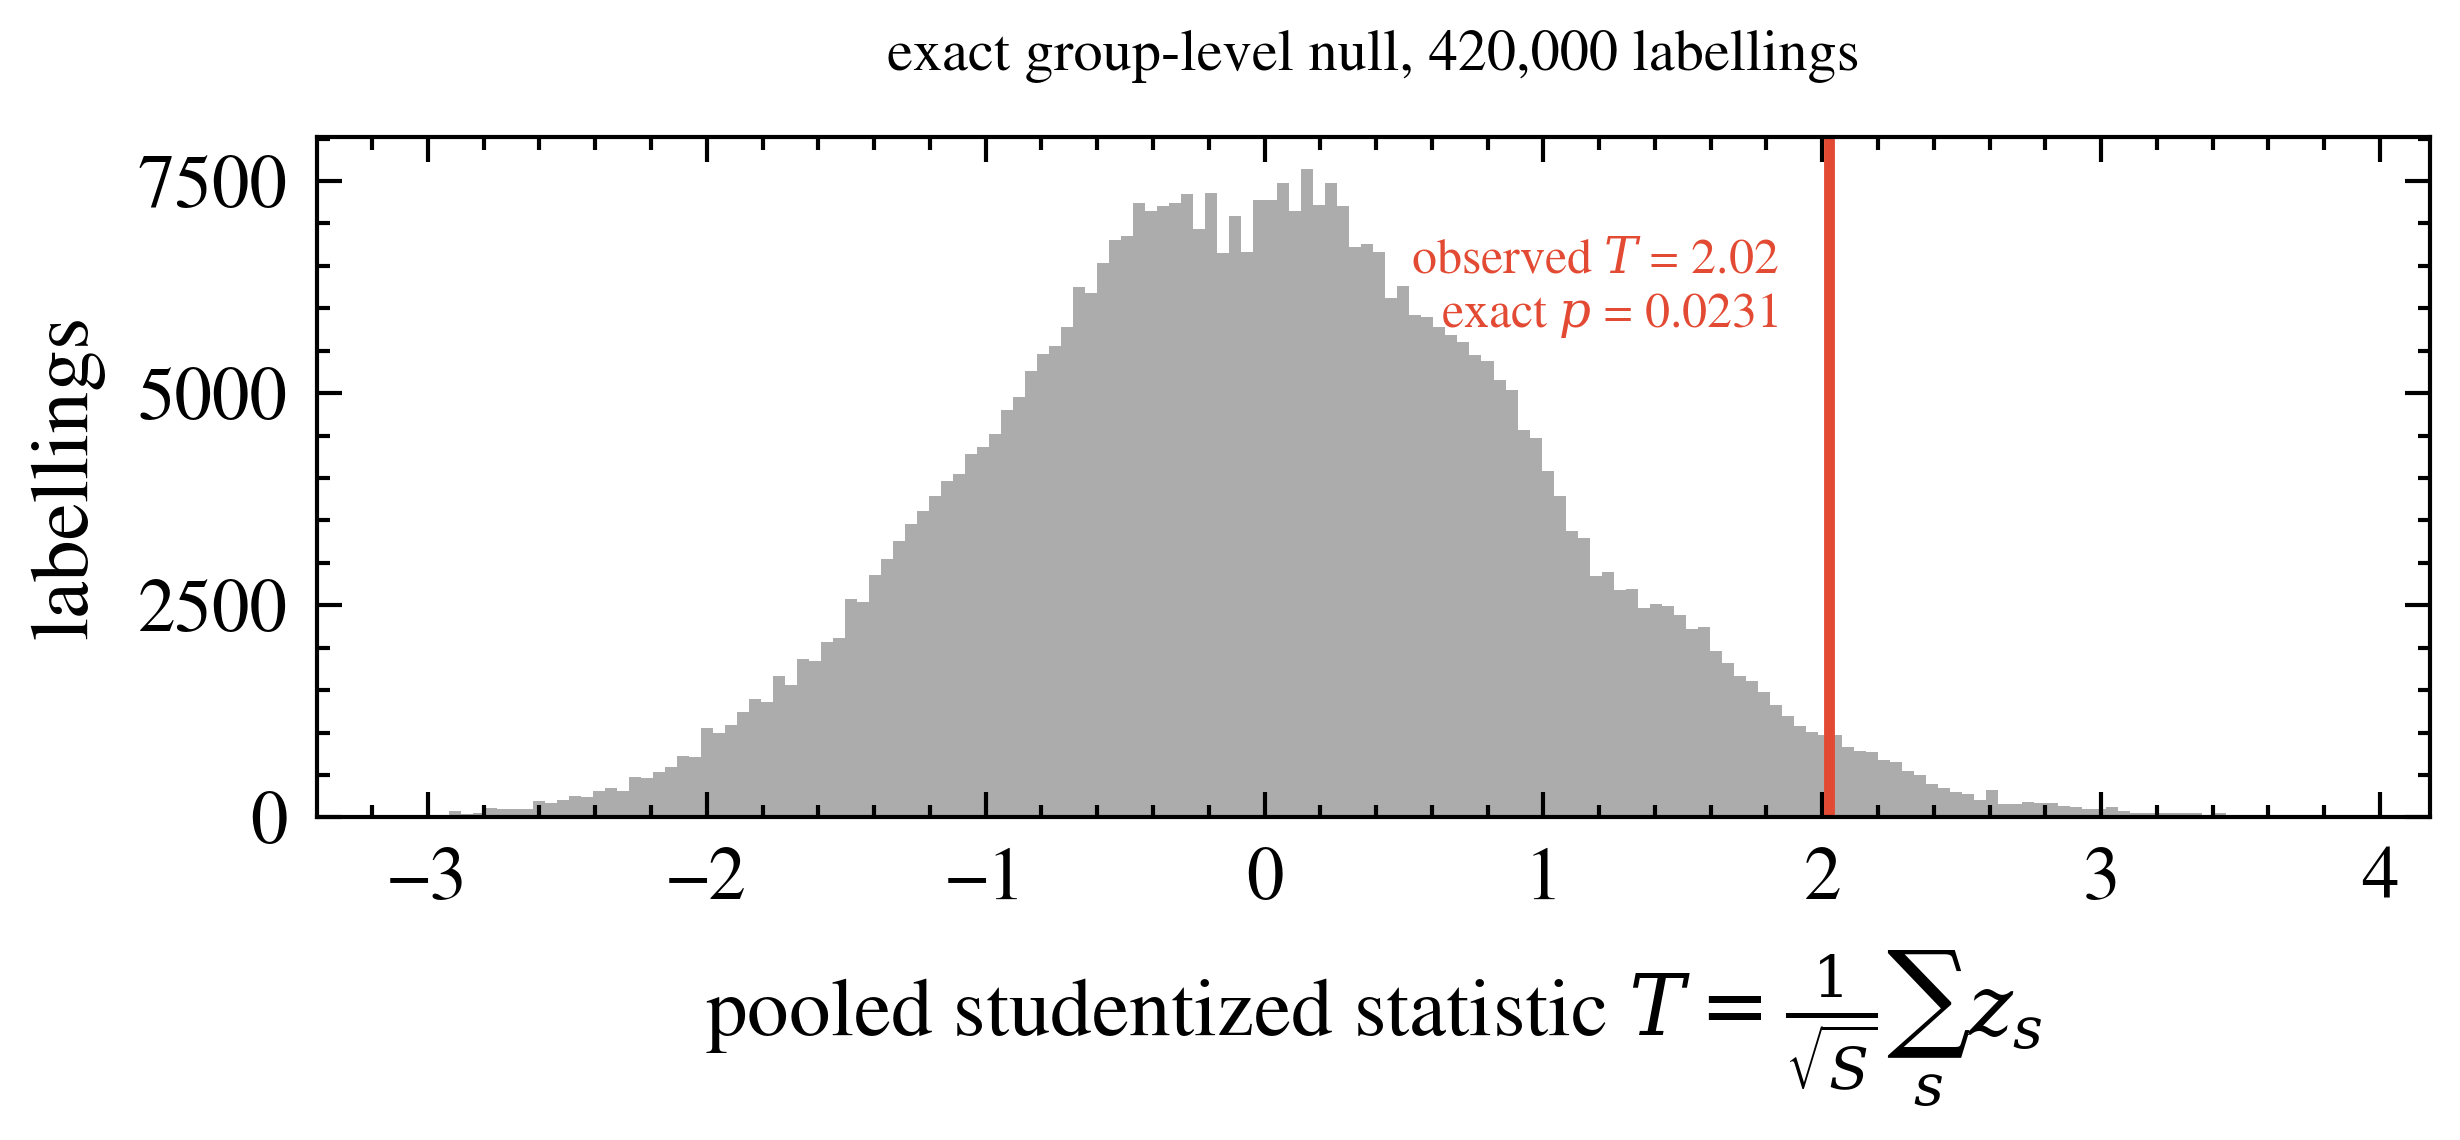

In [7]:
fig, ax = plt.subplots(figsize=(4.2, 2.0))
ax.hist(null_T_z, bins=160, color=COLOR_NS, alpha=0.85, linewidth=0)
ax.axvline(obs_T_z, color=COLOR_DBS_ON, lw=1.3)
ax.annotate(
    f"observed $T$ = {obs_T_z:.2f}\nexact $p$ = {p_group_z:.4f}",
    xy=(obs_T_z, ax.get_ylim()[1] * 0.72),
    xytext=(-6, 0), textcoords="offset points",
    ha="right", fontsize=6, color=COLOR_DBS_ON,
)
ax.set_xlabel(r"pooled studentized statistic $T=\frac{1}{\sqrt{S}}\sum_s z_s$")
ax.set_ylabel("labellings")
ax.set_title(f"exact group-level null, {null_T_z.size:,} labellings", fontsize=7)
fig.savefig(OUT / "fig_5b_03_group_null.png", dpi=300, bbox_inches="tight")
plt.show()

The floor has moved from 0.05–0.067 to $2.4\times10^{-6}$. Whether *this particular cell* clears
$\alpha$ is a separate question from whether the test can answer it — the point is that it now
can, and the answer no longer depends on how many draws were run.

Note also that exhaustive enumeration is **cheaper** than the current sampler: 125 model fits
per cell against 2000, and the resulting p is exact rather than Monte-Carlo noisy.

Two things must be said about this number before it goes anywhere near the thesis:

- **It is one cell of the family**, computed before any multiplicity correction. With ~18–24
  cells, BH at rank 1 needs $p \le 0.05/24 \approx 0.002$ to survive. This cell would not.
- **PDI4_S3 supplies most of it** ($z = 2.70$ against 1.25, 0.20 and $-0.11$) — and PDI4_S3 is
  exactly the session where the block-truncation problem of Part 3 fires. The pooled result
  inherits that defect until it is fixed.

The methodological claim stands regardless: the same data that four separate tests could not
resolve below $p = 0.067$ resolves to $p = 0.023$ once the sessions are pooled under a restricted
permutation, with no refit and no new assumptions about the neural signal.

## Part 5 — Does the replacement actually work? Size and power on synthetic data

Everything above is about what the test *can* return. This part checks that it returns the right
thing. Synthetic data with the same block structure as the real sessions (8 blocks 4/4, 6 blocks
3/3, 6 blocks 3/3, 6 blocks 4/2), block-level random offsets, and a planted mean shift $\delta$
on ON blocks. Four arms:

| arm | what it is |
|---|---|
| **best single session** | the smallest of the four per-session exact p, uncorrected — the most optimistic reading of what the thesis reports now |
| **Fisher** | Fisher combination of the four per-session p (`RESULTS_FIX_PLAN` option 2) |
| **group, raw mean** | pooled permutation test on $\bar T$ |
| **group, studentized** | pooled permutation test on $\frac{1}{\sqrt S}\sum_s z_s$ (recommended) |

At $\delta = 0$ the rejection rate must not exceed $\alpha = 0.05$ — that is the validity check.
Above $\delta = 0$, higher is better.

In [8]:
if SIM is None:
    print("results/group_perm_simulation.json not found — run scripts/simulate_group_permutation.py")
else:
    rows = SIM["rows"]
    deltas = SIM["deltas"]
    ARMS = {
        "best single session": "p_min_session",
        "Fisher": "p_fisher",
        "group, raw mean": "p_group_rawmean",
        "group, studentized": "p_group_studentized",
    }
    power = {
        name: [
            float(np.mean([r[key] <= ALPHA for r in rows if r["delta"] == d]))
            for d in deltas
        ]
        for name, key in ARMS.items()
    }

    print(f"{SIM['n_reps']} replications per delta, alpha = {ALPHA}, "
          f"product space = {SIM['product_size']:,}\n")
    hdr = f"{'delta':>6s} " + "".join(f"{n:>22s}" for n in ARMS)
    print(hdr)
    print("-" * len(hdr))
    for i, d in enumerate(deltas):
        print(f"{d:6.2f} " + "".join(f"{power[n][i]:22.3f}" for n in ARMS))
    print("\nrow at delta = 0 is the empirical size; it must sit at or below 0.05.")

200 replications per delta, alpha = 0.05, product space = 420,000

 delta    best single session                Fisher       group, raw mean    group, studentized
-----------------------------------------------------------------------------------------------
  0.00                  0.030                 0.010                 0.050                 0.035
  0.15                  0.025                 0.000                 0.060                 0.060
  0.30                  0.070                 0.035                 0.150                 0.155
  0.50                  0.160                 0.075                 0.310                 0.320
  0.75                  0.335                 0.430                 0.795                 0.785
  1.00                  0.585                 0.835                 0.970                 0.970

row at delta = 0 is the empirical size; it must sit at or below 0.05.


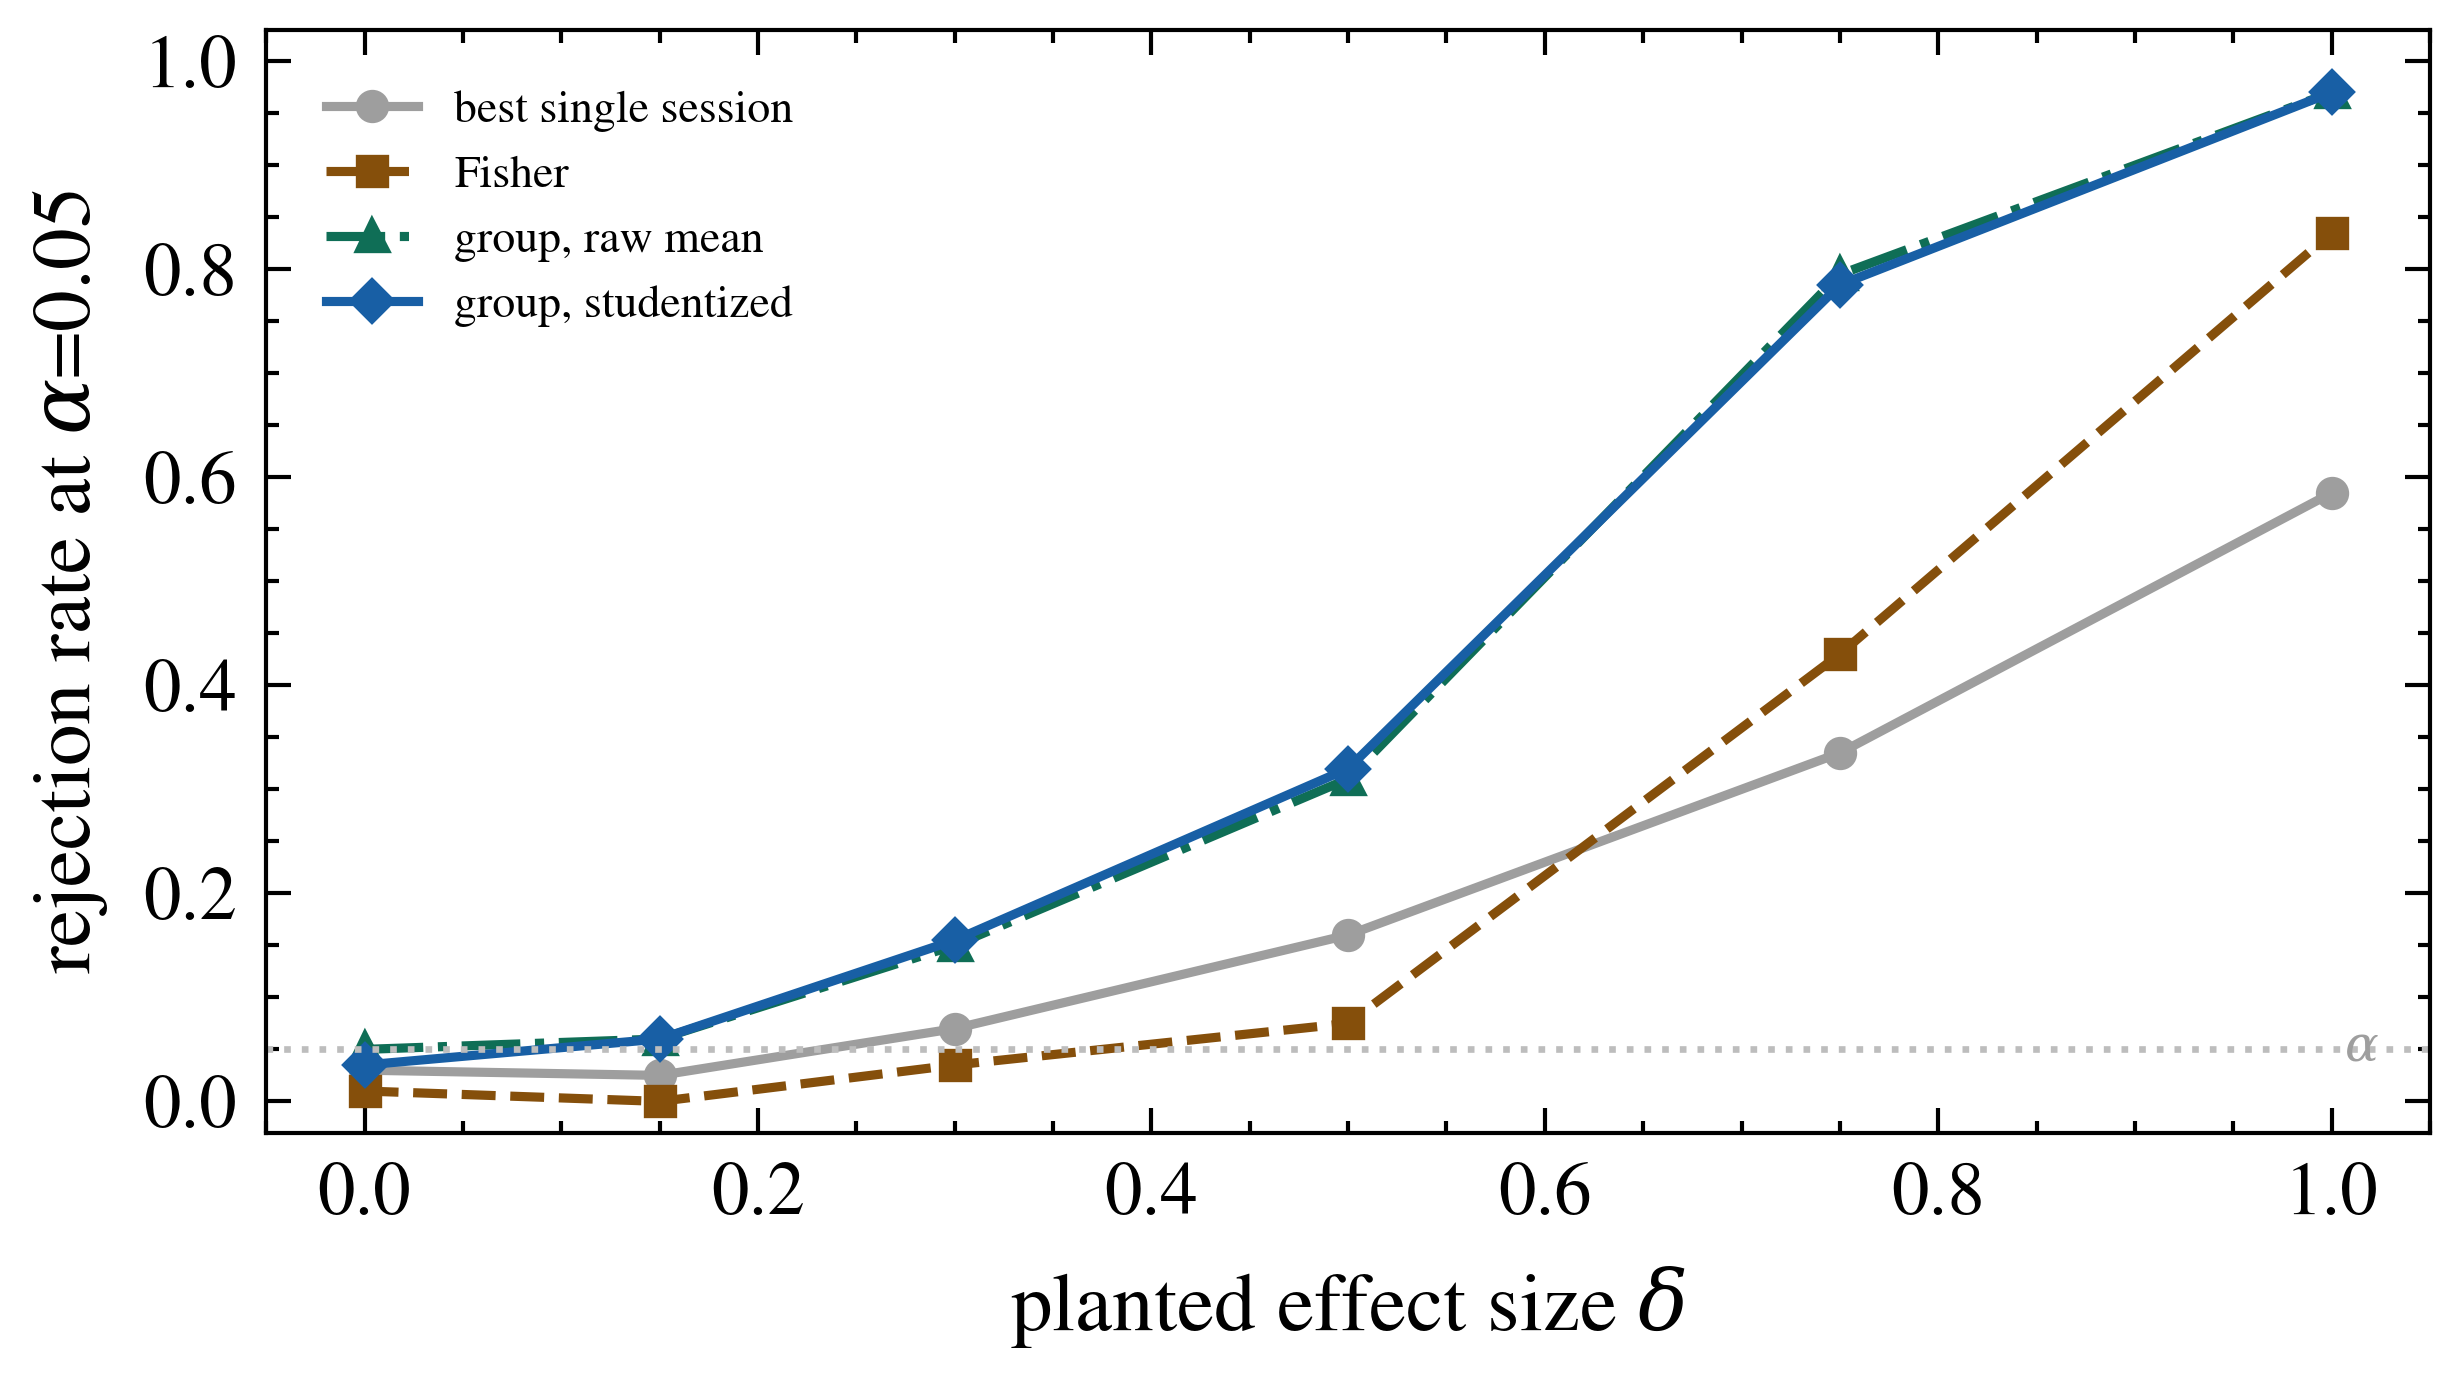

In [9]:
if SIM is not None:
    fig, ax = plt.subplots(figsize=(4.2, 2.4))
    styles = {
        "best single session": (COLOR_NS, "-", "o"),
        "Fisher": ("#854F0B", "--", "s"),
        "group, raw mean": ("#0F6E56", "-.", "^"),
        "group, studentized": (COLOR_PSID, "-", "D"),
    }
    for name, vals in power.items():
        c, ls, mk = styles[name]
        ax.plot(deltas, vals, ls, color=c, marker=mk, ms=3, lw=1.1, label=name)
    ax.axhline(ALPHA, color=COLOR_CHANCE, ls=":", lw=0.8)
    ax.text(deltas[-1], ALPHA, r" $\alpha$", va="center", fontsize=6, color=COLOR_NS)
    ax.set_xlabel(r"planted effect size $\delta$")
    ax.set_ylabel(f"rejection rate at $\\alpha$={ALPHA}")
    ax.set_ylim(-0.03, 1.03)
    ax.legend(fontsize=5.5, loc="upper left", frameon=False)
    fig.savefig(OUT / "fig_5b_04_power.png", dpi=300, bbox_inches="tight")
    plt.show()

## Part 6 — When does studentizing actually matter?

In Part 5 the raw mean and the studentized statistic are indistinguishable. That is expected: a
*uniform* effect loads every session equally, so rescaling changes nothing. The two come apart
when the effect sits in one session — which is the realistic case here, given that the four
sessions differ in how much DBS signal they plausibly carry.

This run plants the effect in one session at a time:

- **PDI1_S2** — 8 blocks, the *smallest* null SD (0.026)
- **PDI1_S4** — 6 blocks, the *largest* null SD (0.145)

In [10]:
LOC_PATH = Path("results/group_perm_localized.json")
LOC = json.loads(LOC_PATH.read_text()) if LOC_PATH.exists() else None

if LOC is None:
    print("results/group_perm_localized.json not found — "
          "run scripts/simulate_localized_effect.py")
else:
    rows = LOC["rows"]
    targets = sorted({r["target"] for r in rows}, key=lambda t: SESSIONS.index(t))
    deltas = LOC["deltas"]
    ARMS_L = {
        "that session alone": "p_target_session",
        "Fisher": "p_fisher",
        "group, raw mean": "p_group_rawmean",
        "group, studentized": "p_group_studentized",
    }
    loc_power = {
        (t, name): [
            float(np.mean([
                r[key] <= ALPHA for r in rows
                if r["delta"] == d and r["target"] == t
            ]))
            for d in deltas
        ]
        for t in targets
        for name, key in ARMS_L.items()
    }

    for t in targets:
        sd = CALIB[t]["null_sd"]
        print(f"\neffect in {t} only  (real null SD = {sd:.3f})")
        hdr = f"{'delta':>6s} " + "".join(f"{n:>22s}" for n in ARMS_L)
        print(hdr)
        print("-" * len(hdr))
        for i, d in enumerate(deltas):
            print(f"{d:6.2f} " + "".join(f"{loc_power[(t, n)][i]:22.3f}" for n in ARMS_L))


effect in PDI1_S2 only  (real null SD = 0.026)
 delta     that session alone                Fisher       group, raw mean    group, studentized
-----------------------------------------------------------------------------------------------
  0.00                  0.020                 0.010                 0.065                 0.060
  0.50                  0.180                 0.030                 0.120                 0.105
  1.00                  0.525                 0.090                 0.220                 0.240
  1.50                  0.945                 0.070                 0.315                 0.365

effect in PDI1_S4 only  (real null SD = 0.145)
 delta     that session alone                Fisher       group, raw mean    group, studentized
-----------------------------------------------------------------------------------------------
  0.00                  0.000                 0.000                 0.040                 0.035
  0.50                  0.000           

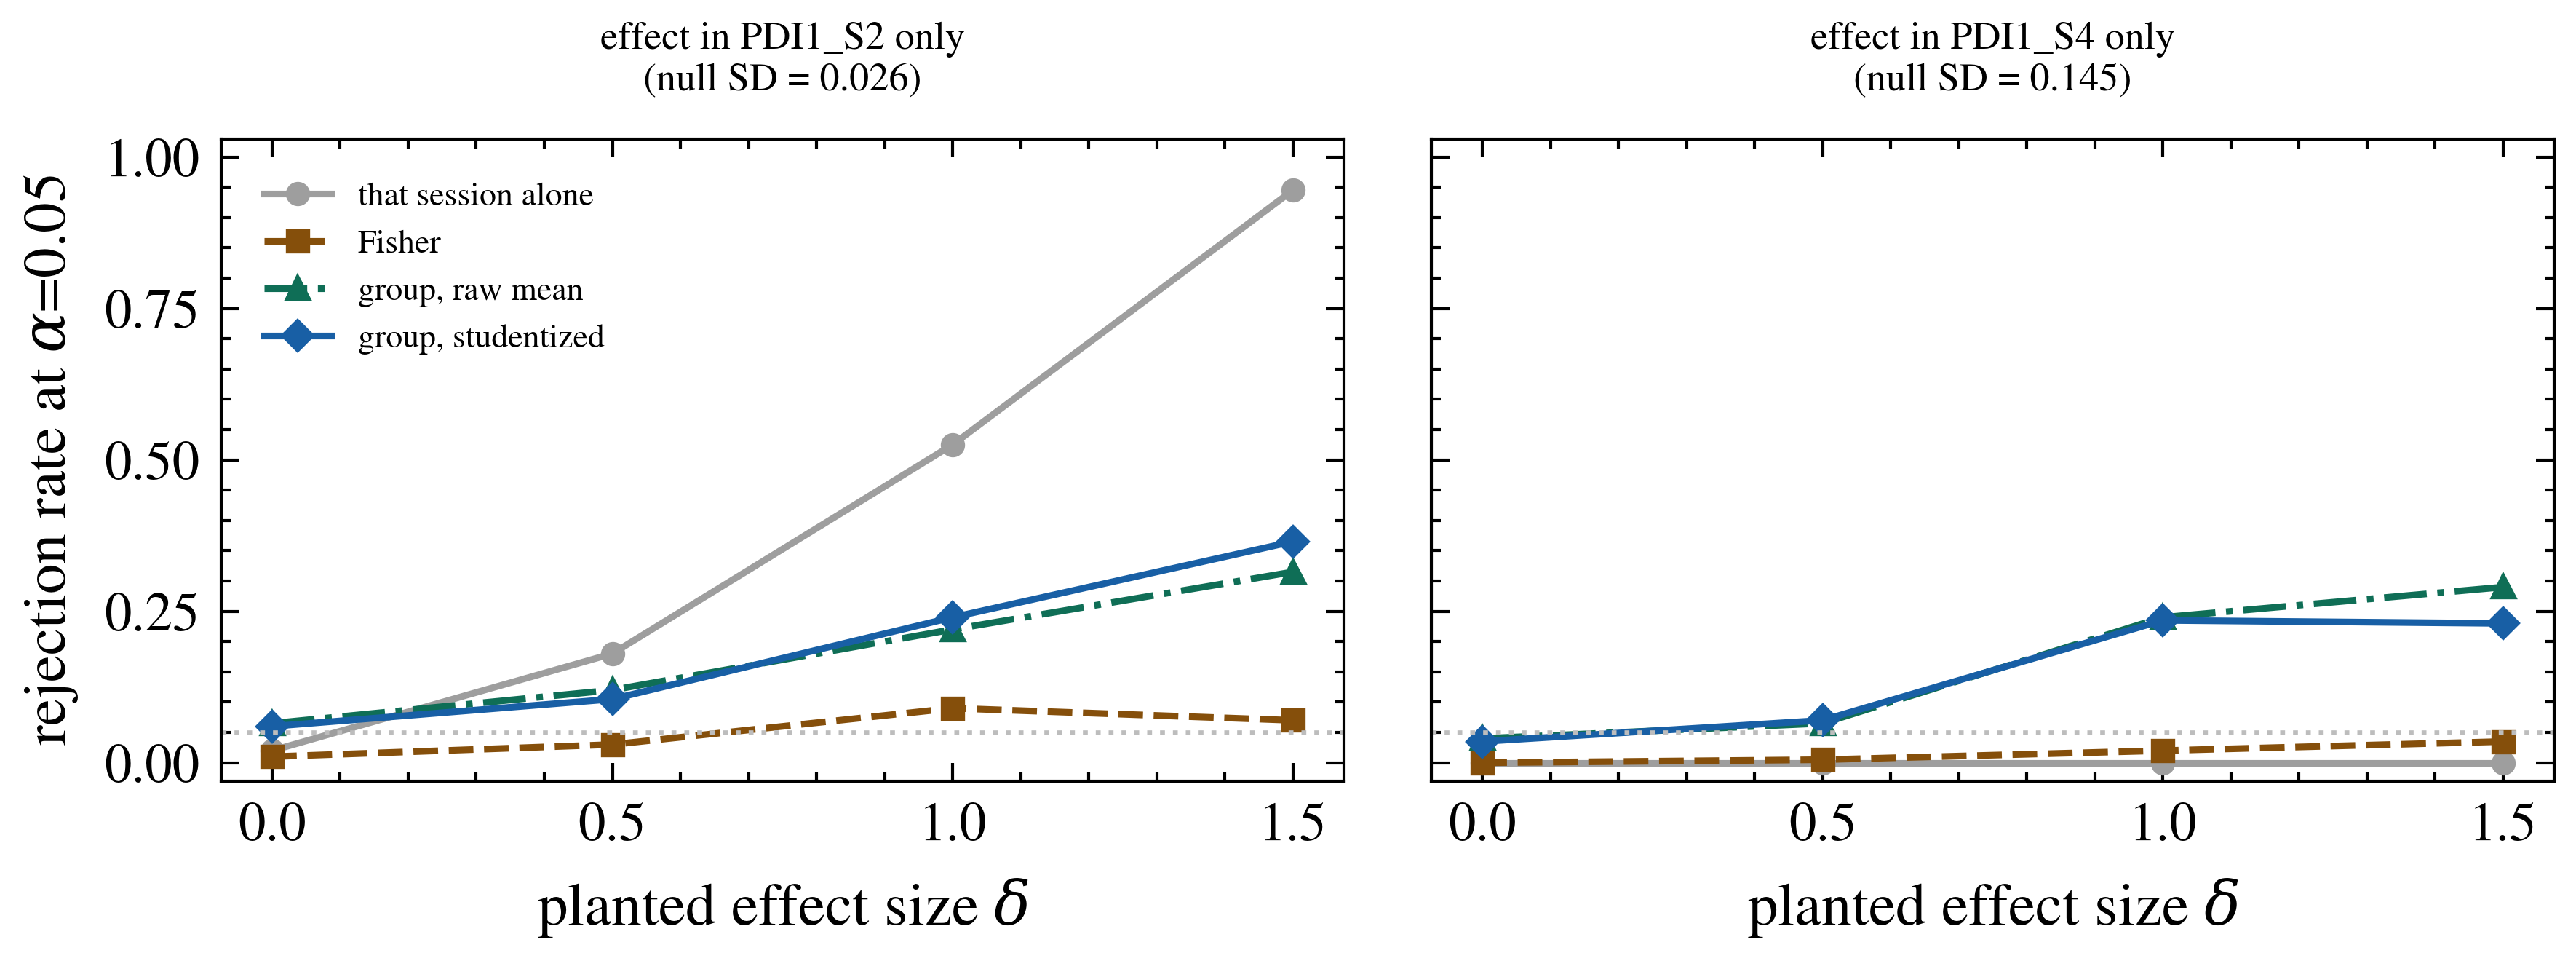

In [11]:
if LOC is not None:
    fig, axes = plt.subplots(1, len(targets), figsize=(6.0, 2.3), sharey=True)
    styles_l = {
        "that session alone": (COLOR_NS, "-", "o"),
        "Fisher": ("#854F0B", "--", "s"),
        "group, raw mean": ("#0F6E56", "-.", "^"),
        "group, studentized": (COLOR_PSID, "-", "D"),
    }
    for ax, t in zip(np.atleast_1d(axes), targets):
        for name in ARMS_L:
            c, ls, mk = styles_l[name]
            ax.plot(deltas, loc_power[(t, name)], ls, color=c, marker=mk,
                    ms=3, lw=1.1, label=name)
        ax.axhline(ALPHA, color=COLOR_CHANCE, ls=":", lw=0.8)
        ax.set_xlabel(r"planted effect size $\delta$")
        ax.set_title(f"effect in {t} only\n(null SD = {CALIB[t]['null_sd']:.3f})", fontsize=6.5)
        ax.set_ylim(-0.03, 1.03)
    np.atleast_1d(axes)[0].set_ylabel(f"rejection rate at $\\alpha$={ALPHA}")
    np.atleast_1d(axes)[0].legend(fontsize=5.5, loc="upper left", frameon=False)
    fig.savefig(OUT / "fig_5b_05_localized_power.png", dpi=300, bbox_inches="tight")
    plt.show()

**Finding 4 — the group test is not a free upgrade, and studentizing buys nothing.**

Two results, both against the simple story:

1. **Where the effect lives decides which test wins.** With the effect confined to **PDI1_S2**
   — the 8-block session, the only one whose floor (0.014) sits below $\alpha$ — the
   single-session test wins outright (0.945 versus 0.365 at $\delta=1.5$): pooling dilutes a
   concentrated effect with three noisy sessions. With the effect confined to **PDI1_S4**, the
   single-session test has power **exactly zero at every effect size**, because its floor is
   0.05 and it can never return $p<\alpha$ no matter how large the effect. The group test
   reaches 0.23–0.29 there.

   So: pooling rescues the three sessions that cannot reject on their own and costs power in the
   one that can. Both halves belong in the write-up.

2. **Studentized and raw-mean are indistinguishable.** 0.365 vs 0.315 in one scenario, 0.230 vs
   0.290 in the other — differences inside the Monte-Carlo noise of 200 replications
   (SE $\approx$ 0.03). The 5.6× SD spread from Part 2 is real, but at these block counts it
   does not translate into a power difference. Prefer the studentized form for readability of
   the per-session contributions; do not claim a power argument for it.

3. **Fisher combination is the worst arm everywhere** (0.005–0.09 across these scenarios). It
   combines p-values that are floored and take only 10–15 distinct values, so it throws away
   most of the information. That settles `RESULTS_FIX_PLAN` option 2 against itself.

## What this means for the code

Confirmed by the numbers above, in order of how much they matter:

1. **The within-model null is a power ceiling** (M1). Three of four sessions cannot return
   $p<0.05$ for any classifier. PDI4_S3 at BA 0.775 returns exactly its floor, 0.067. The
   Results text has to stop reading these as evidence of absence.
2. **`ChronoGroupsSplit` truncation needs a Methods sentence, not a patch.** In PDI4_S3 two
   blocks are train-only and the fold count is 2. The permutation test stays valid; the BAs
   stay valid. Disclose it and move on.
3. **Enumerate, don't sample.** 125 fits per cell for an exact p, against 2000 fits for a
   Monte-Carlo p on a 20-element space. Strictly cheaper and strictly better.
4. **Studentize or not — it does not matter for power.** Null SDs differ 5.6× across sessions
   and a raw mean lets PDI1_S4 own 45% of the pooled variance, but Part 6 shows the two
   statistics reject at indistinguishable rates in both simulation scenarios. Use the
   studentized form because the per-session $z_s$ are readable as a contribution plot, not
   because it buys anything.
5. **No gate on the group path.** `perm_ba_gate = 0.5` stays where it is for the per-cell test
   (a one-sided test on BA < 0.5 would return a large p anyway), but the pooled statistic needs
   every session's contribution on every draw — dropping sessions by their observed BA is
   selection on the outcome and biases the pooled null.
6. **Family and multiplicity.** Sessions collapse into the statistic, so the family shrinks from
   393 tested cells to ~18–24. Fix the family membership in writing before looking at the
   p-values, and keep `Xp_with_dbs` out of it (M25 — it is label leakage by construction).

Still to decide before any of this is written up: whether the LFP separability above ~35 Hz
(`RESULTS_FIX_PLAN` D4/M4, $|r| = 1.000$ on single derivations with sign flips) is neural or
residual stimulation artifact. A test with a $2.4\times10^{-6}$ floor will happily return a
significant result on an artifact — the current test is too weak to detect anything, artifact
included, which is what has been hiding the question.